In [1]:
import json

# Читаем исходный файл
with open('backup.json', 'r') as file:
    data = json.load(file)

# Обрабатываем данные
for item in data:
    # Преобразуем initial_buy
    if isinstance(item['initial_buy'], str):
        item['initial_buy'] = float(item['initial_buy'].replace(' SOL', ''))
    
    # Преобразуем market_cap
    if isinstance(item['market_cap'], str):
        item['market_cap'] = float(item['market_cap'].replace(' SOL', ''))

# Сохраняем в новый файл
with open('backup_cleared.json', 'w') as file:
    json.dump(data, file, indent=4)

In [2]:
import pandas as pd
import json

# Чтение JSON
with open("backup_cleared.json", "r") as f:
    data = json.load(f)

# Преобразование в DataFrame
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.01).astype(int)  # 1 если прибыль/безубыток

# Сохранение в CSV
df[["initial_buy", "market_cap", "price", "sol_amount", "target"]].to_csv("trades.csv", index=False)

In [3]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
rf = RandomForestClassifier(n_estimators=1000, max_depth=10, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
print("Precision:", precision_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_pred))
print("Feature Importance:", pd.Series(rf.feature_importances_, index=X.columns))

Precision: 0.04225352112676056
ROC-AUC: 0.4916666666666667
Feature Importance: initial_buy    0.343201
market_cap     0.330339
price          0.000387
sol_amount     0.326073
dtype: float64


In [4]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

# Данные
df = pd.read_csv("trades.csv")

# Downsampling: балансируем датасет
df_pos = df[df["target"] == 1]
df_neg = df[df["target"] == 0].sample(len(df_pos), random_state=42)
df_balanced = pd.concat([df_pos, df_neg])

# Обучающая выборка из сбалансированных
X_train = df_balanced[["initial_buy", "market_cap", "price", "sol_amount"]]
y_train = df_balanced["target"]

# Тестовая выборка — на реальных данных
X_test = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y_test = df["target"]

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train)

# Порог
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.6).astype(int)

# Метрики
print("Precision:", precision_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, probas))
print("Feature Importance:", pd.Series(model.get_feature_importance(), index=X_train.columns))

print("---------------------------------------")

# Sweep по порогам
for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred = (probas >= threshold).astype(int)
    print(f"Threshold: {threshold}, Precision: {precision_score(y_test, y_pred)}")


Precision: 0.09669811320754718
ROC-AUC: 0.7367434352678004
Feature Importance: initial_buy    31.248424
market_cap     22.242120
price          22.969232
sol_amount     23.540224
dtype: float64
---------------------------------------
Threshold: 0.2, Precision: 0.05978784956605593
Threshold: 0.3, Precision: 0.062436028659160696
Threshold: 0.4, Precision: 0.08006279434850863
Threshold: 0.5, Precision: 0.09320388349514563
Threshold: 0.6, Precision: 0.09669811320754718
Threshold: 0.7, Precision: 0.10283687943262411
Threshold: 0.8, Precision: 0.10283687943262411
Threshold: 0.9, Precision: 0.10984848484848485


In [76]:
from catboost import CatBoostClassifier
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd

# Данные
df = pd.read_csv("trades.csv")

X_train = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y_train = df["target"]

# Подсчет веса классов вручную
class_counts = y_train.value_counts()
total = len(y_train)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)
model.fit(X_train, y_train)

# Предсказания
probas = model.predict_proba(X_train)[:, 1]
y_pred = (probas >= 0.6).astype(int)

# Метрики
print("Precision:", precision_score(y_train, y_pred))
print("ROC-AUC:", roc_auc_score(y_train, probas))
print("Feature Importance:", pd.Series(model.get_feature_importance(), index=X_train.columns))

print("---------------------------------------")

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    y_pred = (probas >= threshold).astype(int)
    print(f"Threshold: {threshold}, Precision: {precision_score(y_train, y_pred)}")


Precision: 0.5973904939422181
ROC-AUC: 0.8176618452699091
Feature Importance: initial_buy    23.891264
market_cap     29.068744
price          22.269232
sol_amount     24.770761
dtype: float64
---------------------------------------
Threshold: 0.2, Precision: 0.25977390485162505
Threshold: 0.3, Precision: 0.36533333333333334
Threshold: 0.4, Precision: 0.40584269662921346
Threshold: 0.5, Precision: 0.4550438596491228
Threshold: 0.6, Precision: 0.5973904939422181
Threshold: 0.7, Precision: 0.7117241379310345
Threshold: 0.8, Precision: 0.7887596899224806
Threshold: 0.9, Precision: 0.889273356401384


In [19]:
###TESTCR
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd
import numpy as np

# Данные
df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

# Downsampling: балансируем датасет
df_pos = df[df["target"] == 1]
df_neg = df[df["target"] == 0].sample(len(df_pos), random_state=23)
df_balanced = pd.concat([df_pos, df_neg])

# Сбалансированные данные для обучения
X_balanced = df_balanced[["initial_buy", "market_cap", "price", "sol_amount"]]
y_balanced = df_balanced["target"]

# Модель
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)

# Кросс-валидация вручную
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precision_scores = []
roc_auc_scores = []

for train_idx, val_idx in cv.split(X_balanced, y_balanced):
    X_train, X_val = X_balanced.iloc[train_idx], X_balanced.iloc[val_idx]
    y_train, y_val = y_balanced.iloc[train_idx], y_balanced.iloc[val_idx]
    
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_val)[:, 1]
    
    y_pred = (probas >= 0.75).astype(int)
    
    precision_scores.append(precision_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, probas))

print("Cross-validated Precision:", np.mean(precision_scores))
print("Cross-validated ROC-AUC:", np.mean(roc_auc_scores))

ValueError: Cannot take a larger sample than population when 'replace=False'

In [6]:
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_score, roc_auc_score
import pandas as pd
import numpy as np

# Данные
df = pd.read_csv("trades.csv")
X = df[["initial_buy", "market_cap", "price", "sol_amount"]]
y = df["target"]

# Подсчет весов классов вручную
class_counts = y.value_counts()
total = len(y)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Модель с учетом веса классов
model = CatBoostClassifier(
    iterations=1000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)

# Кросс-валидация
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
precision_scores = []
roc_auc_scores = []

for train_idx, val_idx in cv.split(X, y):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
    
    model.fit(X_train, y_train)
    probas = model.predict_proba(X_val)[:, 1]
    
    y_pred = (probas >= 0.75).astype(int)
    
    precision_scores.append(precision_score(y_val, y_pred))
    roc_auc_scores.append(roc_auc_score(y_val, probas))

print("Cross-validated Precision:", np.mean(precision_scores))
print("Cross-validated ROC-AUC:", np.mean(roc_auc_scores))


Cross-validated Precision: 0.0365079365079365
Cross-validated ROC-AUC: 0.5031175161139214


In [23]:
###TESTPNL

from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json

# Загрузка данных
with open("backup.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.01).astype(int)

# Сплитим оригинальные данные
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=42)

# Балансируем обучающую выборку
df_pos = df_train[df_train["target"] == 1]
df_neg = df_train[df_train["target"] == 0].sample(len(df_pos), random_state=42)
df_bal = pd.concat([df_pos, df_neg])

# Подготовка X/y
features = ["initial_buy", "market_cap", "price", "sol_amount", "delta_get_price", "buy_price"]
X_train, y_train = df_bal[features], df_bal["target"]
X_test, y_test = df_test[features], df_test["target"]
results_test = df_test["result"]

# Обучаем
model = CatBoostClassifier(
    iterations=2000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42
)
model.fit(X_train, y_train)

# Предсказания и PnL
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.7).astype(int)

pnl = results_test[y_pred == 1]
print("Predicted as profitable trades:", len(pnl))
print("Sum:", sum(pnl))
print("Mean PnL per predicted=1:", pnl.mean())
print("All PnLs:\n", pnl.tolist())


importances = model.get_feature_importance(Pool(X_train, y_train), type='FeatureImportance')
for name, score in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")

Predicted as profitable trades: 58
Sum: -1.7704601717695112
Mean PnL per predicted=1: -0.03052517537533641
All PnLs:
 [2.0626095727970065e-10, 0.0, 0.0, 0.02005254179909922, -0.01859267731579021, 0.0, 0.12510132206554037, 0.0, 0.0, 0.0, 0.005856249696711925, 0.0, -0.45979956576418923, -0.0006222935060177761, 6.696933710898681e-11, 0.0, 0.0, 0.02841357953599747, -0.17206396033278984, -0.0018089381531857, 0.0, -0.2580255452770201, -0.06061898407012065, -0.06792640917426163, 0.0, 0.0, -0.0714377650585731, 0.0, 0.0, -0.009498743906621733, -0.016099539413120593, -0.19417522355318462, -0.24608256836682624, 0.0, -0.08074220634654478, 9.983611445277434e-11, 0.0, -0.18154301868152253, -0.060522051641718574, -0.13615962216908314, 0.0726511805475908, 0.030624398289389645, 0.006001883366797825, -0.0019586124668198274, 0.0, 0.05990394215219548, 0.13662426303096936, -0.10643956039009228, 9.983611445277434e-11, -0.14730914205072337, 0.0, 0.0, 0.0, 0.29011977911576425, -0.32394810575925054, 0.02145106

#### 

In [105]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json

# Загрузка данных
with open("backup.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.005).astype(int)

# Трейн/тест сплит
df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=60)

# Подсчет весов классов по всей трейновой выборке
class_counts = df_train["target"].value_counts()
total = len(df_train)
weights = {
    0: total / class_counts[0],
    1: total / class_counts[1]
}

# Подготовка X/y
features = ["initial_buy", "market_cap", "price", "sol_amount", "delta_get_price", "buy_price"]
X_train, y_train = df_train[features], df_train["target"]
X_test, y_test = df_test[features], df_test["target"]
results_test = df_test["result"]

# Обучение с class_weights
model = CatBoostClassifier(
    iterations=2000,
    max_depth=6,
    learning_rate=0.1,
    verbose=0,
    random_state=42,
    class_weights=[weights[0], weights[1]]
)
model.fit(X_train, y_train)

# Предсказания и PnL
probas = model.predict_proba(X_test)[:, 1]
y_pred = (probas >= 0.7).astype(int)

pnl = results_test[y_pred == 1]
print("Predicted as profitable trades:", len(pnl))
print("Sum:", sum(pnl))
print("Mean PnL per predicted=1:", pnl.mean())
print("All PnLs:\n", pnl.tolist())

importances = model.get_feature_importance(Pool(X_train, y_train), type='FeatureImportance')
for name, score in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"{name}: {score:.4f}")


Predicted as profitable trades: 9
Sum: 0.04070996477932373
Mean PnL per predicted=1: 0.004523329419924859
All PnLs:
 [0.0, 1.2862086913396192e-10, -0.22710781520255557, -0.002995709514516476, 0.02841357953599747, 0.0, 0.06405632558369423, 0.0, 0.17834358424808322]
buy_price: 46.4258
delta_get_price: 27.1283
initial_buy: 7.8170
market_cap: 7.4870
price: 5.9007
sol_amount: 5.2411


model.save_model("catboost_model_balanced.cbm")


In [106]:
model.save_model("catboost_model_balanced.cbm")


KeyError: 'target'

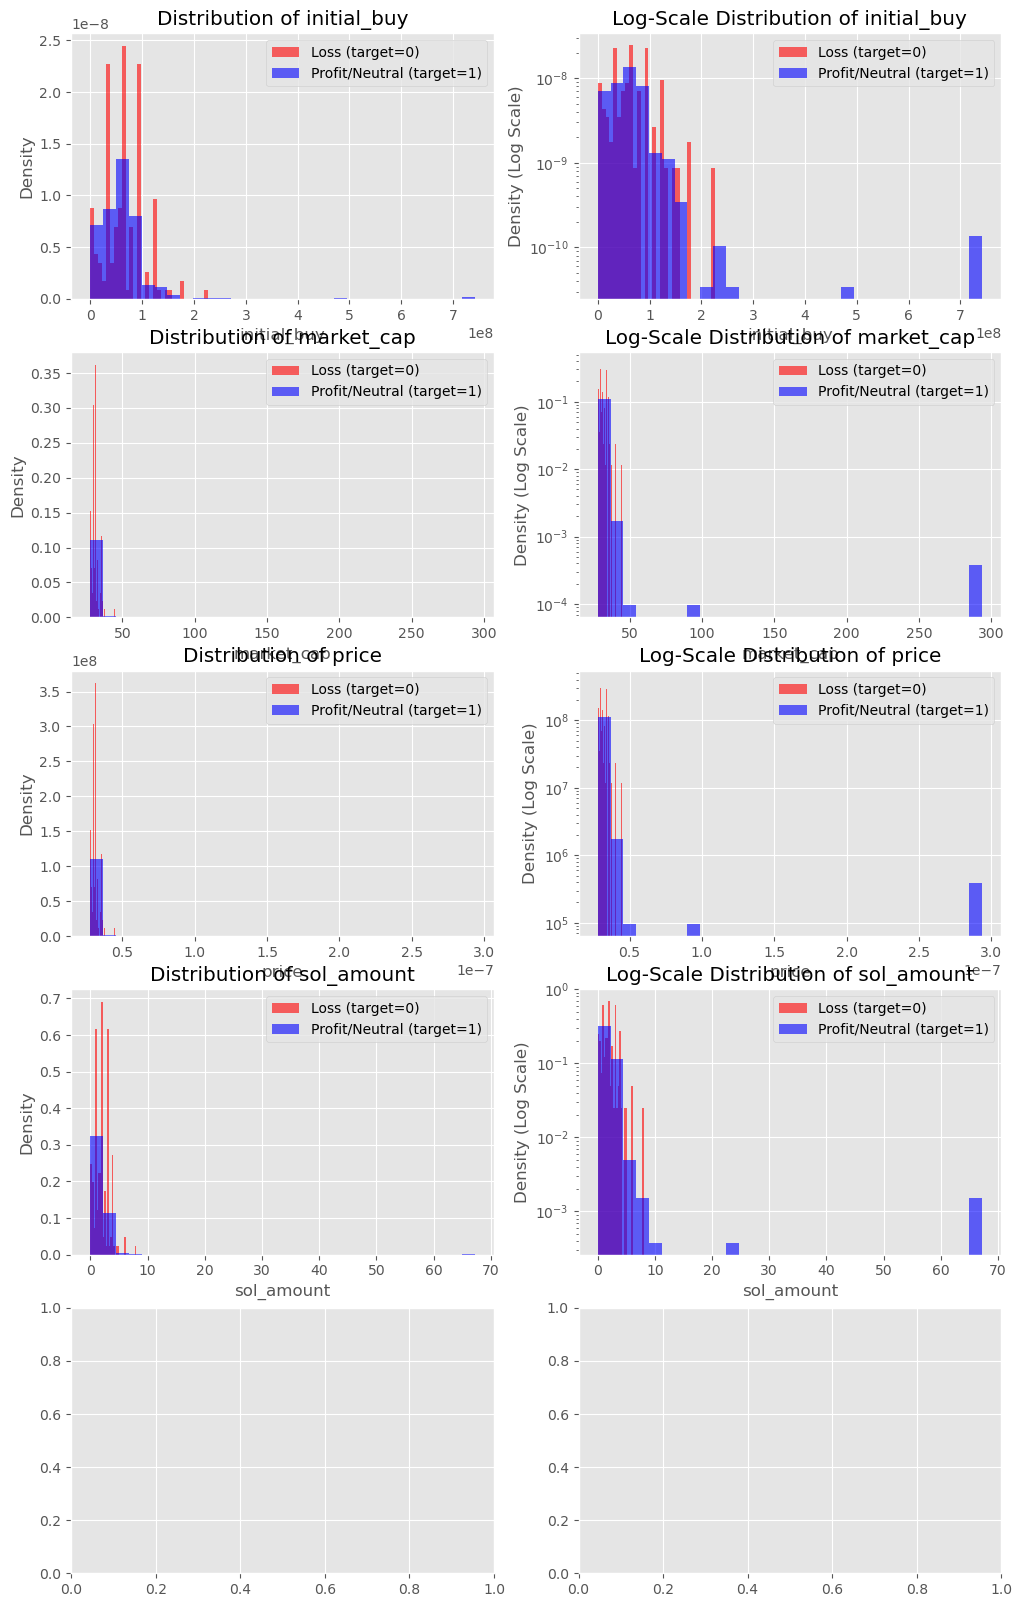

In [13]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns  # Если установлен Seaborn

# Чтение JSON
with open("backup_cleared.json", "r") as f:
    data = json.load(f)

# Преобразование в DataFrame
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.0).astype(int)  # 1 если прибыль/безубыток

# Сохранение в CSV
df[["initial_buy", "market_cap", "price", "sol_amount", "target"]].to_csv("trades.csv", index=False)

# Загрузка данных
df = pd.read_csv("trades.csv")
df_json = pd.DataFrame(data)  # Для result из JSON

# Параметры для визуализации
features = ["initial_buy", "market_cap", "price", "sol_amount", "result"]
colors = {0: "red", 1: "blue"}  # Цвета для target=0 и target=1
labels = {0: "Loss (target=0)", 1: "Profit/Neutral (target=1)"}

# Настройка стиля
plt.style.use("ggplot")  # Используем встроенный стиль Matplotlib
# Если установлен Seaborn, можно использовать:
# sns.set_style("whitegrid")

# Создание сетки графиков
fig, axes = plt.subplots(nrows=len(features), ncols=2, figsize=(12, 4 * len(features)))

# Построение гистограмм
for i, feature in enumerate(features):
    # Используем df_json для result, иначе df
    data_source = df_json if feature == "result" else df
    
    # Гистограмма для target=0
    axes[i, 0].hist(
        data_source[data_source["target"] == 0][feature],
        bins=30,
        color=colors[0],
        alpha=0.6,
        label=labels[0],
        density=True
    )
    # Гистограмма для target=1
    axes[i, 0].hist(
        data_source[data_source["target"] == 1][feature],
        bins=30,
        color=colors[1],
        alpha=0.6,
        label=labels[1],
        density=True
    )
    axes[i, 0].set_title(f"Distribution of {feature}")
    axes[i, 0].set_xlabel(feature)
    axes[i, 0].set_ylabel("Density")
    axes[i, 0].legend()

    # Логарифмическая шкала
    axes[i, 1].hist(
        data_source[data_source["target"] == 0][feature],
        bins=30,
        color=colors[0],
        alpha=0.6,
        label=labels[0],
        density=True,
        log=True
    )
    axes[i, 1].hist(
        data_source[data_source["target"] == 1][feature],
        bins=30,
        color=colors[1],
        alpha=0.6,
        label=labels[1],
        density=True,
        log=True
    )
    axes[i, 1].set_title(f"Log-Scale Distribution of {feature}")
    axes[i, 1].set_xlabel(feature)
    axes[i, 1].set_ylabel("Density (Log Scale)")
    axes[i, 1].legend()

# Установка компактного расположения
plt.tight_layout()
plt.savefig("distributions.png", dpi=300, bbox_inches="tight")  # Сохранение графика
plt.show()

# Статистика по околонулевым result
okolonul = df_json[df_json["result"].between(-0.05, 0.05)]
print(f"Околонулевые трейды (-0.05 ≤ result ≤ 0.05): {len(okolonul)} ({len(okolonul)/len(df_json)*100:.1f}%)")
print(f"Распределение target среди околонулевых:")
print(okolonul["target"].value_counts(normalize=True))

In [52]:
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import json

# Загрузка данных
with open("backup_cleared.json", "r") as f:
    data = json.load(f)
df = pd.DataFrame(data)
df["target"] = (df["result"] >= 0.3).astype(int)

features = ["initial_buy", "market_cap", "price", "sol_amount", "delta_get_price", "buy_price"]

all_pnls = []

for seed in range(10, 110, 10):  # Прогоны с 10 по 100
    df_train, df_test = train_test_split(df, test_size=0.2, stratify=df["target"], random_state=seed)

    class_counts = df_train["target"].value_counts()
    total = len(df_train)
    weights = {
        0: total / class_counts[0],
        1: total / class_counts[1]
    }

    X_train, y_train = df_train[features], df_train["target"]
    X_test, y_test = df_test[features], df_test["target"]
    results_test = df_test["result"]

    model = CatBoostClassifier(
        iterations=1000,
        max_depth=6,
        learning_rate=0.1,
        verbose=0,
        random_state=seed,
        class_weights=[weights[0], weights[1]]
    )
    model.fit(X_train, y_train)

    probas = model.predict_proba(X_test)[:, 1]
    y_pred = (probas >= 0.8).astype(int)
    pnl = results_test[y_pred == 1]

    all_pnls.extend(pnl.tolist())
    print(f"[Seed {seed}] Predicted as profitable trades: {len(pnl)}, Mean PnL: {pnl.mean():.6f}")

# Финальный результат
if all_pnls:
    print("\n--- Aggregated Results ---")
    print(f"Total predicted as profitable: {len(all_pnls)}")
    print(f"Final Mean PnL per predicted=1: {np.mean(all_pnls):.6f}")
else:
    print("No profitable predictions across all seeds.")


[Seed 10] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 20] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 30] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 40] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 50] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 60] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 70] Predicted as profitable trades: 0, Mean PnL: nan
[Seed 80] Predicted as profitable trades: 2, Mean PnL: 0.027021
[Seed 90] Predicted as profitable trades: 2, Mean PnL: -0.202806
[Seed 100] Predicted as profitable trades: 0, Mean PnL: nan

--- Aggregated Results ---
Total predicted as profitable: 4
Final Mean PnL per predicted=1: -0.087892
